## Food recommendation based on grouping of foods with similar nutrient contents and classification to developed groups
Selected models = k-means - cluster numerical data (nutrients) + dtree for classification

In [17]:
# libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, accuracy_score
from sklearn.model_selection import train_test_split
import sklearn.tree as dt
import pickle as pkl

proj_dir = "D:/r/KenyaDSM"
foods_path = proj_dir + '/' + "data/foods"

### Prepare data

In [18]:
foods = pd.read_csv(foods_path + '/' + 'veg_k_mg.csv')
foods.tail()

,Code,Vegetable,Magnesium,Potassium
31,4033,"Stinging nettle, leaves, raw",133.0,524
32,4034,Sweet Potato (Leaves),61.0,620
33,4035,"Tomato, green, raw",14.0,225
34,4036,"Tomato, red, ripe, raw",9.5,126
35,4038,"Vine (African) spinach, picked leaves, raw",40.0,446


In [19]:
# convert datatypes - code
foods.dtypes

Code           int64
Vegetable     object
Magnesium    float64
Potassium      int64
dtype: object

In [20]:
foods["Code"] = foods["Code"].astype(str)
foods["Potassium"] = foods["Potassium"].astype(float)
foods.dtypes

Code          object
Vegetable     object
Magnesium    float64
Potassium    float64
dtype: object

<Axes: xlabel='Magnesium', ylabel='Potassium'>

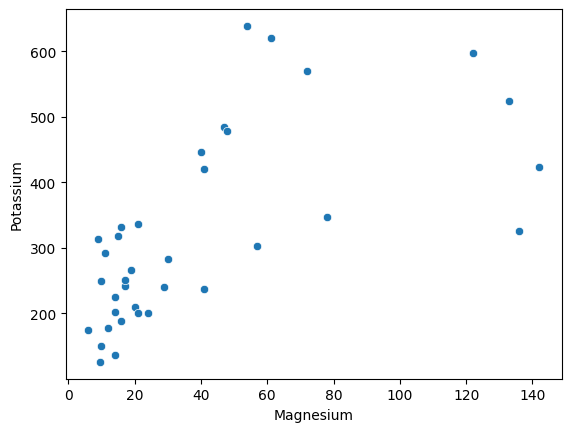

In [21]:
# visualise distribution
sns.scatterplot(data=foods, x='Magnesium', y='Potassium')

many foods have both relatively low mg and potassium values. select clusters with low, medium and high vals (low might have highest number of foods); generate df of only values

In [22]:
# nutrient splitting
nutrients = foods.iloc[:, [2,3]]
nutrients

,Magnesium,Potassium
0,122.0,597.0
1,20.0,210.0
2,41.0,421.0
3,21.0,336.0
4,10.0,250.0
5,29.0,241.0
6,9.0,313.0
7,10.0,151.0
8,6.0,174.0
9,17.0,242.0


### K-Means Modelling

- cluster with elbow analysis and silhouette score to determine suitable number of clusters

In [23]:
# normalise nutrient values
scaler = StandardScaler()
nutrients = scaler.fit_transform(nutrients)
nutrients

array([[ 2.17009825,  1.95691931],
       [-0.51700368, -0.78095977],
       [ 0.03622319,  0.71178567],
       [-0.49065954,  0.11044272],
       [-0.78044505, -0.49797485],
       [-0.27990645, -0.56164645],
       [-0.80678918, -0.0522736 ],
       [-0.78044505, -1.19836252],
       [-0.88582159, -1.03564619],
       [-0.59603609, -0.55457183],
       [-0.59603609, -0.49090023],
       [-0.75410091, -0.20084068],
       [-0.54334782, -0.37770626],
       [-0.62238023, -0.93660147],
       [ 0.19428801,  1.16456154],
       [-0.6750685 , -1.30448186],
       [-0.49065954, -0.85170599],
       [-0.25356231, -0.26451229],
       [ 0.37869696,  2.25405348],
       [ 0.03622319, -0.58287032],
       [-0.6750685 , -0.83755675],
       [-0.41162713, -0.84463137],
       [-0.64872436, -0.01690049],
       [ 2.53891616,  0.0396965 ],
       [ 0.45772937, -0.12301983],
       [-0.72775677, -1.0073477 ],
       [ 2.69698098,  0.72593492],
       [ 0.22063214,  1.11503918],
       [ 0.85289142,

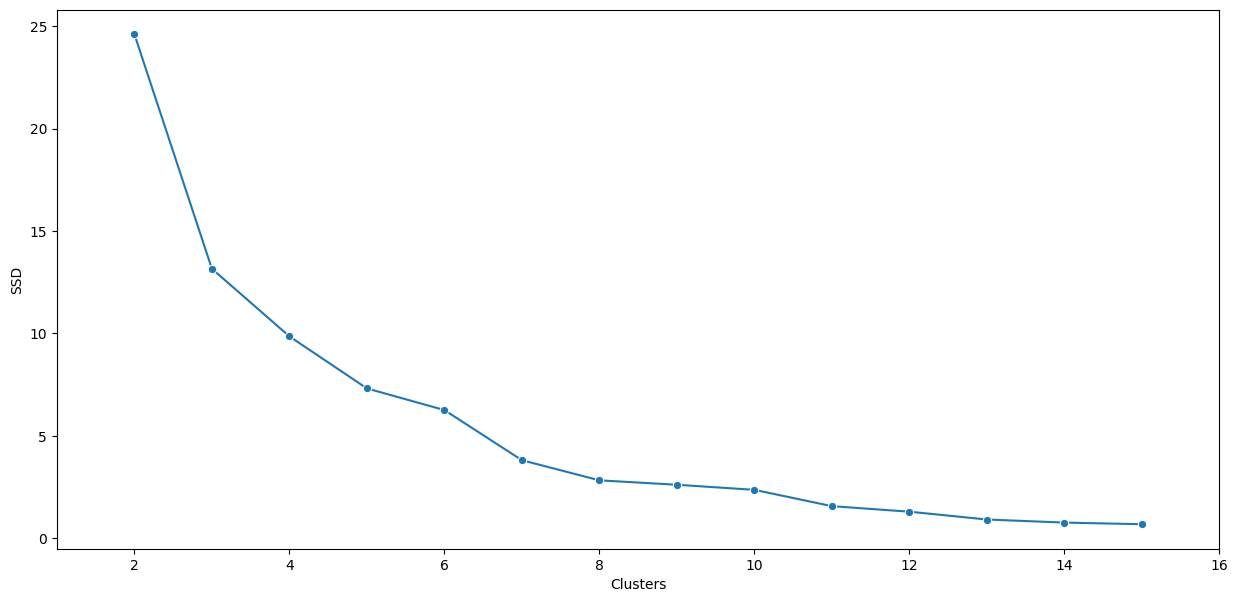

In [24]:
clusters = list(range(2,16)) # test clusters from 2 to 15
ssd = [] # sum of squared distances

for k in clusters:
    km = KMeans(n_clusters=k, random_state=0, n_init="auto")
    km.fit(nutrients)
    ssd.append(km.inertia_)

# elbow plot
plt.figure(figsize=(15,7))
ax = sns.lineplot(x=clusters, y=ssd, marker="o", dashes=False)
ax.set_xlabel('Clusters')
ax.set_ylabel('SSD')
ax.set(xlim=(1,16))
plt.plot();

- elbow point at 3/6/7

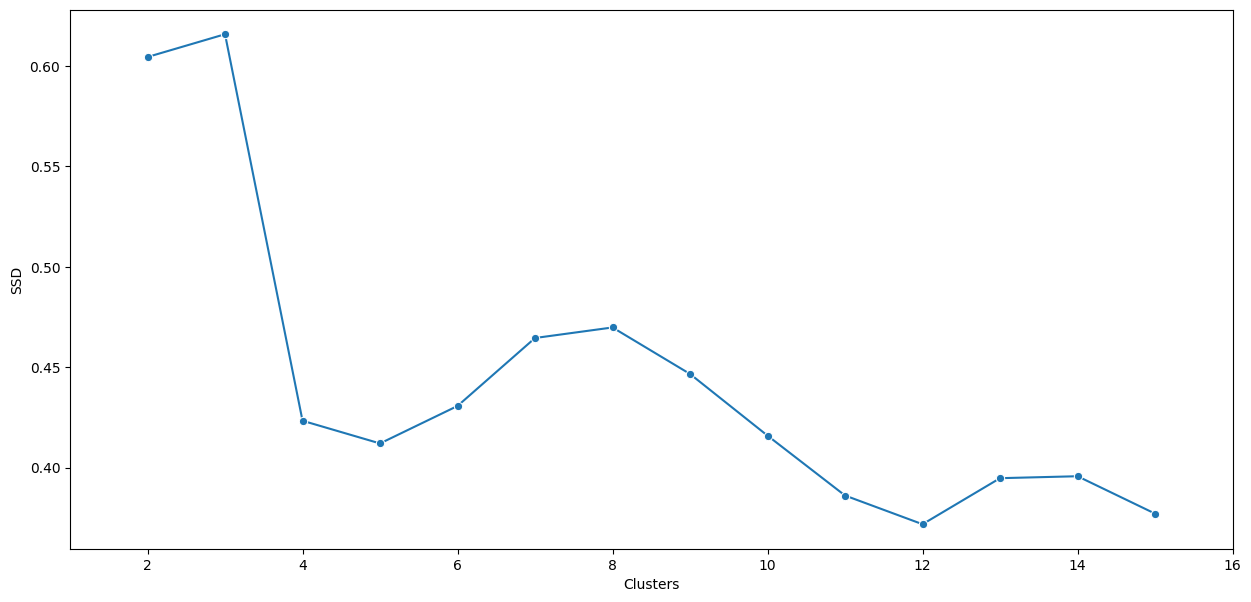

In [25]:
# silhouette score for verification
clusters = list(range(2,16)) # test clusters from 2 to 15
ssc = [] # sum of squared distances

for k in clusters:
    km = KMeans(n_clusters=k, random_state=0, n_init="auto")
    km.fit(nutrients)
    km_labels = km.labels_
    ssc.append(silhouette_score(nutrients, km_labels))

# elbow plot
plt.figure(figsize=(15,7))
ax = sns.lineplot(x=clusters, y=ssc, marker="o", dashes=False)
ax.set_xlabel('Clusters')
ax.set_ylabel('SSD')
ax.set(xlim=(1,16))
plt.plot();

- settled on 6 clusters. remodel with 3 clusters and set to nutrient data

In [26]:
km = KMeans(n_clusters=3, random_state=0, n_init="auto")
km.fit(nutrients)
foods['Category'] = km.labels_
foods

,Code,Vegetable,Magnesium,Potassium,Category
0,4001,"Amaranth, leaves, picked, raw",122.0,597.0,2
1,4002,"Bitter gourd, whole, different varieties, raw",20.0,210.0,0
2,4003,"Black (African) nightshade, indigenous, leaves...",41.0,421.0,1
3,4004,"Broccoli, tops and stems, raw",21.0,336.0,0
4,4005,"Cabbage, leaf head, Chinese, raw",10.0,250.0,0
5,4006,"Cabbage, leaf head, red raw",29.0,241.0,0
6,4007,"Cabbage, leaf head, white, raw",9.0,313.0,0
7,4008,"Capsicum (sweet peper), green, raw",10.0,151.0,0
8,4009,"Capsicum (sweet peper), red, raw",6.0,174.0,0
9,4010,"Capsicum (sweet peper), yellow, raw",17.0,242.0,0


##### Visualise clusters

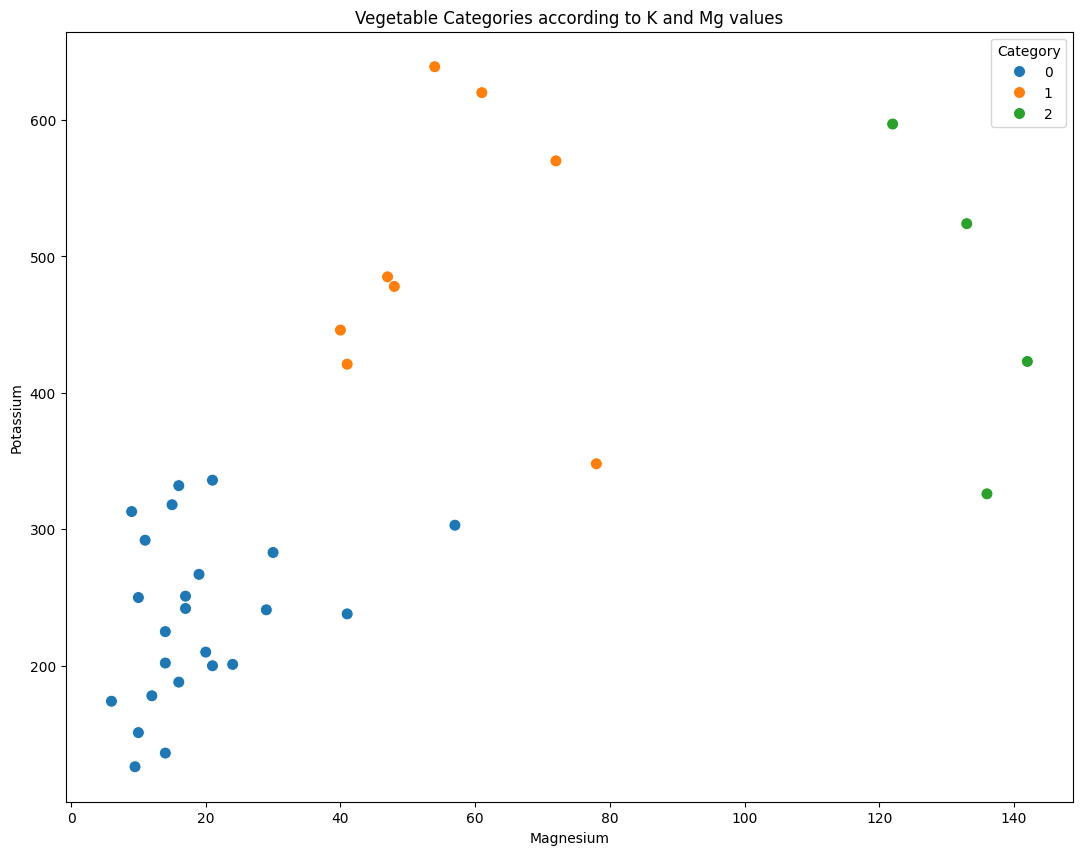

In [27]:
plt.figure(figsize=(13,10))
sns.scatterplot(data=foods, x='Magnesium', y='Potassium', hue='Category', palette="tab10", s=75)
plt.title("Vegetable Categories according to K and Mg values")
plt.legend(title='Category')
plt.show()

In [28]:
# export to csv for use in DB and app
foods['Category'] = foods['Category'].astype(str)
print(foods.dtypes)
foods.to_csv(foods_path + '/' + 'cat_veg.csv', index=False)
foods_fn = 'models/foods_km.pkl'
pkl.dump(km, open(foods_fn, 'wb'))

Code          object
Vegetable     object
Magnesium    float64
Potassium    float64
Category      object
dtype: object


### DTree Potassium Classifier

In [44]:
# split foods into train and test
X, y = foods.iloc[:, [3]], foods.iloc[:, 4]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(28, 1)
(8, 1)
(28,)
(8,)


In [45]:
# Dtree modelling
dtree = dt.DecisionTreeClassifier(criterion = 'gini')
dtree.fit(X_train, y_train)
y_pred = dtree.predict(X_test)

print("Accuracy: ",accuracy_score(y_test, y_pred))

Accuracy:  0.75


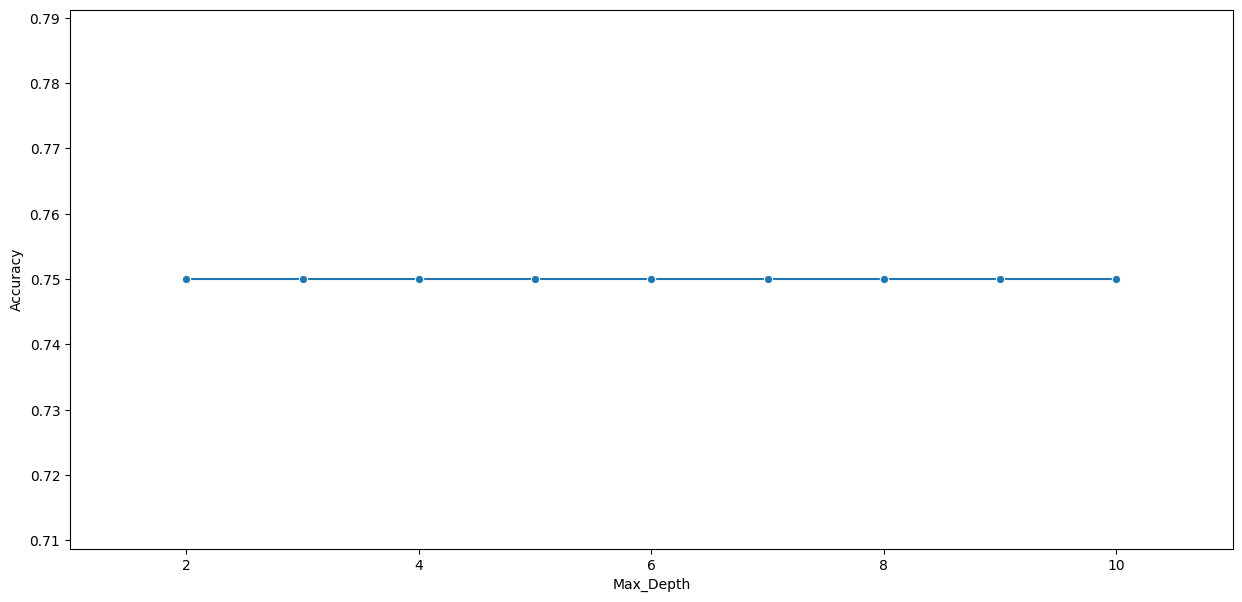

In [49]:
# attempt optimisation with depth of trees

depth = list(range(2,11)) # test clusters from 2 to 10
gini = []

for k in depth:
    dtree1 = dt.DecisionTreeClassifier(criterion='gini', max_depth=k)
    dtree1.fit(X_train, y_train)
    y_pred1 = dtree1.predict(X_test)
    gini.append(accuracy_score(y_test, y_pred1))

# accuracy plot
plt.figure(figsize=(15,7))
ax = sns.lineplot(x=depth, y=gini, marker="o", dashes=False)
ax.set_xlabel('Max_Depth')
ax.set_ylabel('Accuracy')
ax.set(xlim=(1,11))
plt.plot();

- save model at 4 trees max_depth for use in app.

In [ ]:
dtree = dt.DecisionTreeClassifier(criterion = 'gini', max_depth=2)
dtree.fit(X_train, y_train)
foods_fn = 'models/foods_dt.pkl'
pkl.dump(dtree, open(foods_fn, 'wb'))